In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))

from methods.utils import government_feedback, normalized_sigmoid

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


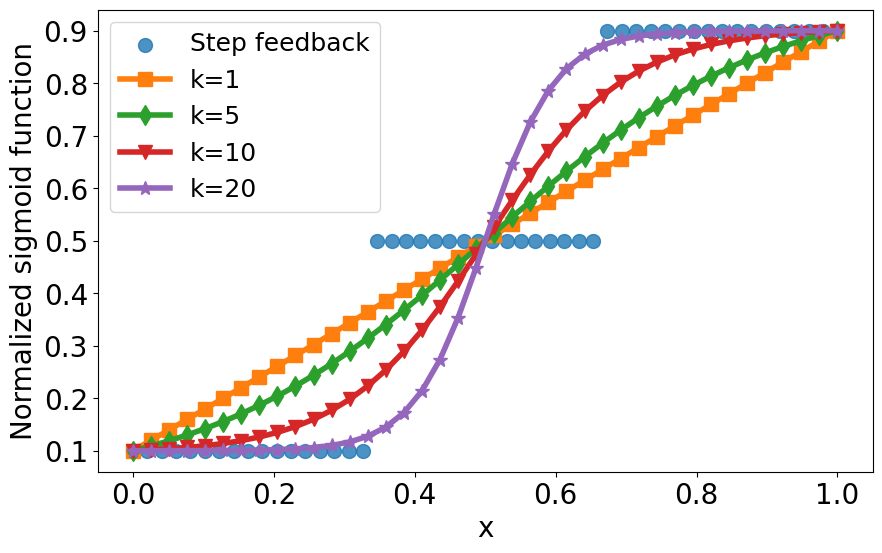

In [8]:
# Create input values from 0 to 1
x = torch.linspace(0, 1, 40)
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
print(default_colors)
# Visualize the function with default parameters
y = normalized_sigmoid(x)

plt.figure(figsize=(10, 6))

xlm, xmh, gl, gm, gh = 1/3, 2/3, 0.1, 0.5, 0.9

x_values = torch.linspace(0, 1, 50)
response = government_feedback(x_values, xlm, xmh, gl, gm, gh).numpy()
x_values = x_values.numpy()

plt.scatter(x_values[x_values < xlm], response[x_values < xlm], 
            s=100, c='#1f77b4', marker='o', alpha=0.8)
plt.scatter(x_values[(xmh > x_values)& (x_values > xlm)], response[(xmh > x_values)& (x_values > xlm)],
            s=100, c='#1f77b4', marker='o', alpha=0.8)
plt.scatter(x_values[x_values > xmh], response[x_values > xmh],
            s=100, c='#1f77b4', marker='o', alpha=0.8, label=f"Step feedback")


# Try different parameter combinations
params = [ 1,5,10,20]
si = ['s-', 'd-', 'v-', '*-']
# plt.plot(time_scale, mcmc_communities_data[0][0:21,:].mean(dim=1), 'o-', linewidth=4, markersize=10, label='Step feedback')

for i in np.arange(len(params)):
    y = normalized_sigmoid(x, k = params[i])
    plt.plot(x.numpy(), y.numpy(), si[i], linewidth=4, markersize=10, label=f"k={params[i]}",color=default_colors[i+1])
# Add labels and title
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Normalized sigmoid function', fontsize=20)
plt.xlabel('x', fontsize=20)
plt.legend(fontsize=18)
# plt.show()
# Save the figure
plt.savefig('../figs/Feedback/feedback.svg', bbox_inches='tight')
plt.savefig('../figs/Feedback/feedback.png', dpi=600, bbox_inches='tight')